In [99]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

In [101]:
df = pd.read_csv("loan_data_set.csv")

df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [105]:
#Check for NaN / missing values, in ApplicantIncome columns
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

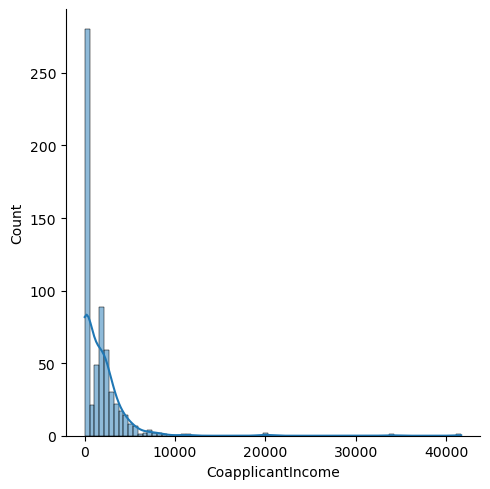

In [107]:
sns.displot(x = df["CoapplicantIncome"], kde = True)

In [108]:
#Using scikit-learn to handle missing values, must be in 2D array
si = SimpleImputer(strategy = "mean")
df["CoapplicantIncome"] = si.fit_transform(df[["CoapplicantIncome"]])

In [109]:
df["CoapplicantIncome"].describe()

count      614.000000
mean      1621.245798
std       2926.248369
min          0.000000
25%          0.000000
50%       1188.500000
75%       2297.250000
max      41667.000000
Name: CoapplicantIncome, dtype: float64

C:\Users\Cresht\AppData\Local\Temp\ipykernel_11584\2576912712.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[(coapp <= max_iqr) & (coapp >= min_iqr)]


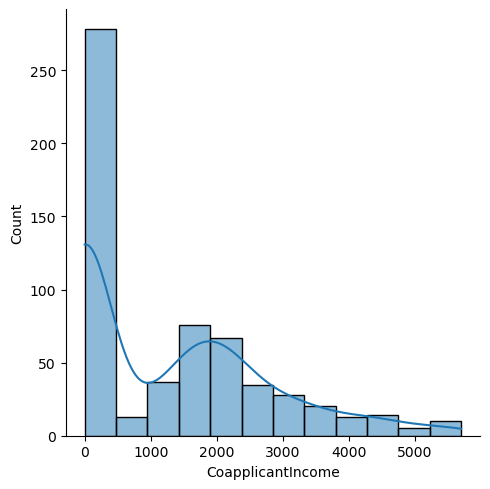

In [110]:
#Remove outliers
coapp = df["CoapplicantIncome"]
coapp = coapp.sort_values()

q3 = coapp.quantile(0.75)
q1 = coapp.quantile(0.25)
iqr = q3 - q1
max_iqr = q3 + 1.5 * iqr
min_iqr = q1 - 1.5 * iqr

df = df[(coapp <= max_iqr) & (coapp >= min_iqr)]

#Reset the index for further analysis (avoiding overlapped numerical values)
df = df.reset_index(drop=True)

sns.displot(x = df["CoapplicantIncome"], kde = True)

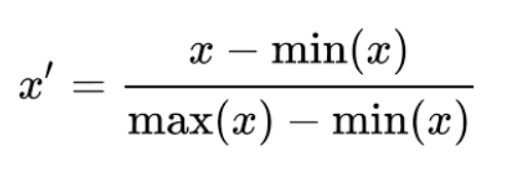

In [114]:
### Min - Max Scaler ###

img = mpimg.imread("min-max scaling.png")
plt.imshow(img)
plt.axis("off")
plt.show()

C:\Users\Cresht\AppData\Local\Temp\ipykernel_11584\1464429483.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x = df["CoapplicantIncome"])
C:\Users\Cresht\AppData\Local\Temp\ipykernel_11584\1464429483.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x = df["CoapplicantIncome_nm"])


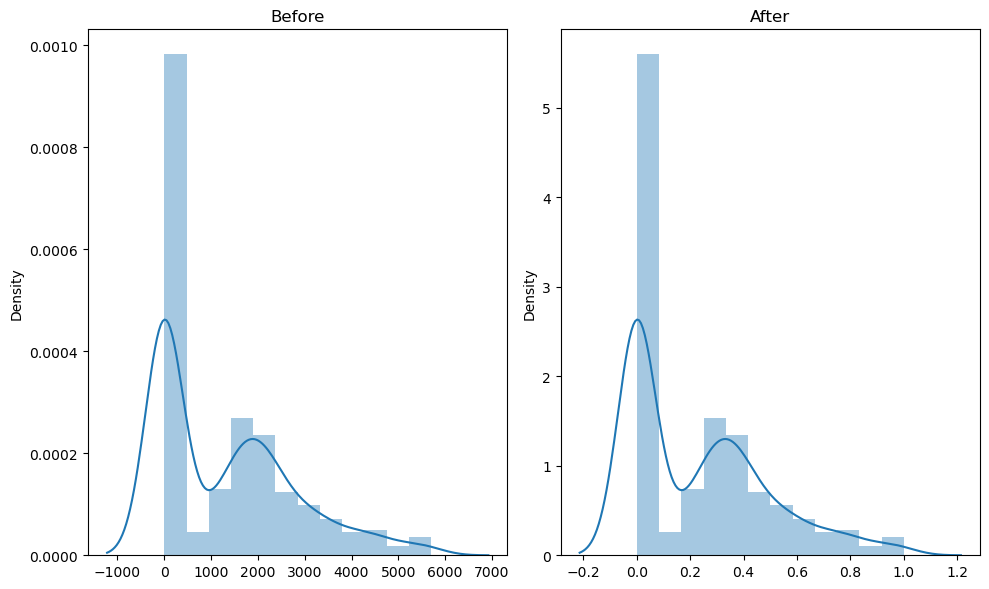

In [119]:
scaler = MinMaxScaler()

df["CoapplicantIncome_nm"] = scaler.fit_transform(df[["CoapplicantIncome"]])

plt.figure(figsize = (10, 6))

plt.subplot(1,2,1)
plt.title("Before")
sns.distplot(x = df["CoapplicantIncome"])

plt.subplot(1,2,2)
plt.title("After")
sns.distplot(x = df["CoapplicantIncome_nm"])

plt.tight_layout()
plt.show()

### Suggestions ###
1. Using median imputation for skewed variables.
2. Experimenting with a log or Box-Cox transformation if the skewness remains problematic.
3. Implementing consistent pipelines to prevent data leakage between training and testing phases.
4. Updating visualization functions to newer Seaborn APIs for better clarity and maintainability.